In [23]:
import nbimporter
import cepairsimplementation as ce
import random
import numpy as np
import math
import test_synthetic as synth
import csv
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from keras import layers, models, optimizers, regularizers, initializers 
from sklearn.model_selection import train_test_split
from scipy.ndimage import gaussian_filter
import itertools

if not hasattr(np, "trapezoid"):
    np.trapezoid = np.trapz

In [24]:
def load_weights(filename='data/dataset_weights.csv', metric=None):
    """
    Load weights for a specific metric and their labels from a CSV file.

    Parameters
    ----------
    filename : str
        Path to the CSV file.
    metric : str
        Name of the metric column to load (e.g., 'Accuracy').

    Returns
    -------
    weights : list of float
        The weights for the specified metric.
    weight_labels : list of str
        Corresponding labels for each weight.

    Raises
    ------
    ValueError
        If metric is not provided or not found in the CSV header.
    """
    if metric is None:
        raise ValueError("metric must be specified to load the corresponding weight column")

    weight_labels = []
    weights = []
    with open(filename, 'r', newline='') as f:
        reader = csv.DictReader(f)
        # Ensure metric exists
        if metric not in reader.fieldnames:
            raise ValueError(f"Metric '{metric}' not found in file. Available columns: {reader.fieldnames}")

        for row in reader:
            weight_labels.append(row['label'])
            weights.append(float(row[metric]))

    return weights, weight_labels


def getData(metric="Accuracy", weights_file='data/dataset_weights.csv', base_dir='generate_txt'):
    """
    Load examples and corresponding weights for a specified metric by label folders.

    Parameters
    ----------
    metric : str, optional
        The metric column to load from the weights CSV (default 'Accuracy').
    weights_file : str, optional
        Path to the weights CSV file.
    base_dir : str, optional
        Base directory containing example subfolders named by label.

    Returns
    -------
    examples : list of (x, y)
        List of synthetic examples loaded.
    weights_out : list of float
        Corresponding weight value for each example based on the specified metric.
    """
    # Load only the specified metric
    weights_values, weight_labels = load_weights(weights_file, "Auroc")
    examples = []
    weights_out = []

    for label, w in zip(weight_labels, weights_values):
        folder = os.path.join(base_dir, label)
        if not os.path.isdir(folder):
            continue
        if w==0:
            continue
        # synth module should provide getSynthetic returning iterable of (x, y)
        syn = synth.getSynthetic(folder)
        if len(syn)%20!=0:
            print("wrong one", label, folder)
        for x, y in syn:
            examples.append(np.array((x, y)))
            weights_out.append(w)

    return examples, weights_out

In [25]:
def vector_to_image_np(x_t, y_t, image_size):
    # Scale to pixel indices and convert to ints
    x_t=ce.minmax_scale(x_t)
    y_t=ce.minmax_scale(y_t)
    x_t=np.array(x_t)
    xi = np.clip((x_t * (image_size - 1)).astype(np.int64), 0, image_size - 1)
    yi = np.clip((y_t * (image_size - 1)).astype(np.int64), 0, image_size - 1)

    # Prepare blank image
    img = np.zeros((image_size, image_size), dtype=np.float32)
    #plt.figure(figsize=(5, 5))
    #plt.plot(xi, yi, 'ro')
    # If x_t, y_t are higher-dimensional, squeeze down to 1D index arrays
    xi_flat = np.squeeze(xi)
    yi_flat = np.squeeze(yi)

    # Set the pixel locations to 1.0
    img[yi_flat, xi_flat] = 1.0
    #img = gaussian_filter(img, sigma=1.0)
    return img

def vector_to_image_density(x_t, y_t, image_size):
    # Scale to [0,1]
    x_t = ce.minmax_scale(x_t)
    y_t = ce.minmax_scale(y_t)

    # Convert scaled coords to integer pixel indices
    xi = np.clip((x_t * (image_size - 1)).astype(np.int64), 0, image_size - 1)
    yi = np.clip((y_t * (image_size - 1)).astype(np.int64), 0, image_size - 1)

    # Flatten in case of extra dimensions
    xi_flat = xi.ravel()
    yi_flat = yi.ravel()

    # Total number of points
    n_points = len(xi_flat)
    if n_points == 0:
        return np.zeros((image_size, image_size), dtype=np.float32)

    # Create an empty image for counts
    counts = np.zeros((image_size, image_size), dtype=np.float32)

    # For each point, increment the corresponding pixel count
    # Faster version using flat indexing:
    flat_idxs = yi_flat * image_size + xi_flat
    binc = np.bincount(flat_idxs, minlength=image_size*image_size)
    counts = binc.reshape((image_size, image_size))

    # Normalize to get density: fraction of total points per pixel
    density_img = counts / n_points
    density_img=density_img/np.max(density_img) # Normalize to [0,1]
    # Optional: apply Gaussian smoothing to the density image
    density_img = gaussian_filter(density_img, sigma=1.0)
    # 
    
    return density_img

def getImgs(examples,size=200, mode="binary"):
    imgs=[]
    for example in examples:
        x,y=example
        if mode=="density":
            imgs.append(vector_to_image_density(x,y,size))
        else:
            imgs.append(vector_to_image_np(x,y,size))
    imgs = np.array(imgs)
    return imgs 

In [26]:
def labeling(examples, weights):
    """
    For each contiguous set of examples (determined by equal weights), assign labels
    such that half are 0 and half are 1 (assuming even-sized sets). Then flip
    examples with label 0 along axis 0.

    Args:
        examples (array-like): Array of examples to be labeled and potentially flipped.
        weights (array-like): Array of weights indicating grouping of examples into sets.
                              Contiguous elements with equal weight belong to the same set.

    Returns:
        flipped_examples: Copy of examples with flips applied for label 0.
        labels: Numpy array of assigned labels (0 or 1) for each example.
    """
    examples = examples.copy()
    weights = np.asarray(weights)
    n = len(examples)

    labels = np.empty(n, dtype=int)

    # Find segment boundaries where weight changes
    # We assume at least one element
    start = 0
    for i in range(1, n + 1):
        # If end of array or weight changes, process current segment
        if i == n or weights[i] != weights[start]:
            segment_end = i
            segment_len = segment_end - start
            # Determine counts (assuming even segment_len)
            half = segment_len // 2
            seg_labels = np.array([0] * half + [1] * (segment_len - half))
            np.random.shuffle(seg_labels)
            labels[start:segment_end] = seg_labels
            start = i

    # Apply flips for label 0
    for idx, lbl in enumerate(labels):
        if lbl == 0:
            examples[idx] = np.flip(examples[idx], axis=0)
    return examples, labels

def labelingv2(examples):
    examples = examples.copy()  
    n = len(examples)
    # zeros = floor(n/2), ones = n - zeros
    num_zeros = n // 2
    num_ones = n - num_zeros
    # build and shuffle labels
    labels = np.array([0]*num_zeros + [1]*num_ones)
    rng = np.random.default_rng(20)
    np.random.shuffle(labels)

    # apply flips for label 0
    for i, lbl in enumerate(labels):
        if lbl == 0:
            examples[i] = np.flip(examples[i], axis=0)
    return examples, labels

def labelingv3(examples, weights):
    """
    Expand each example into two: the original (label=1) and its flipped version (label=0).
    Doubles the weight vector correspondingly, then shuffles examples, labels, and weights.

    Args:
        examples (list): List of input examples.
        weights (list or array-like): Sequence of length n of weights.

    Returns:
        tuple:
            list: Shuffled expanded examples of length 2*n.
            np.ndarray: Corresponding labels (0 for flipped, 1 for original) of length 2*n.
            np.ndarray: Corresponding weights of length 2*n.
    """
    # Copy inputs to avoid in-place modification
    examples = examples.copy()
    weights = list(weights)
    n = len(examples)

    # Prepare original and flipped examples
    original_examples = examples.copy()
    original_labels = [1] * n
    flipped_examples = [np.flip(ex, axis=0) for ex in examples]
    flipped_labels = [0] * n

    # Combine
    all_examples = original_examples + flipped_examples
    all_labels = original_labels + flipped_labels
    all_weights = weights + weights

    # Shuffle in unison
    indices = list(range(2 * n))
    np.random.shuffle(indices)
    shuffled_examples = [all_examples[i] for i in indices]
    shuffled_labels = np.array([all_labels[i] for i in indices], dtype=int)
    shuffled_weights = np.array([all_weights[i] for i in indices])

    return shuffled_examples, shuffled_labels, shuffled_weights


In [27]:
def build_binary_classifier(input_shape, n_convs=3,n_dense=3, filter_size=3, kernel_init='glorot_uniform',bias_init=initializers.Zeros, activation='relu',pooling_size=2, conv_start=32, dense_start=256, backs=False, l2=0.01):
    l2_reg = regularizers.l2(l2)
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))

    # Convolutional blocks
    for i in range(n_convs):
        f = conv_start * (2 ** i)  # Number of filters
        # First conv layer in block
        model.add(
            layers.Conv2D(
                filters=f,
                kernel_size=(filter_size, filter_size),
                kernel_initializer=kernel_init,
                activation=activation,
                kernel_regularizer=l2_reg,
                padding='same'
            )
        )
        # Optional second conv in block
        if backs:
            model.add(
                layers.Conv2D(
                    filters=f,
                    kernel_size=(filter_size, filter_size),
                    kernel_initializer=kernel_init,
                    activation=activation,
                    kernel_regularizer=l2_reg,
                    padding='same'
                )
            )
        # Pooling
        model.add(
            layers.MaxPooling2D(
                pool_size=(pooling_size, pooling_size),
                padding='same'
            )
        )

    model.add(layers.Flatten())

    # Dense layers
    for j in range(n_dense):
        u = int(dense_start / (2 ** j))  # Number of units
        model.add(
            layers.Dense(
                units=u,
                activation=activation,
                kernel_regularizer=l2_reg,
                kernel_initializer=kernel_init,
            )
        )

    # Output layer
    model.add(
        layers.Dense(
            units=1,
            activation='sigmoid',
            kernel_regularizer=l2_reg,
            kernel_initializer=kernel_init,
        )
    )

    return model

In [28]:
def keras_nn2(d,model=None,size=200,per=0.9):
    x,y=d
    if x.shape[1]>1 or y.shape[1]>1:
        return np.nan
    x,y=ce.remove_outliers(x,y,per=per)
    x=x.reshape(-1,1)
    y=y.reshape(-1,1)
    x = ce.minmax_scale(x)
    y = ce.minmax_scale(y)
    img=vector_to_image_np(x,y,size)
    img = np.expand_dims(img, axis=-1)
    probxy=model.predict(np.array([img]), batch_size=1,verbose=0)[0][0]

    img2=vector_to_image_np(y,x,size)
    img2 = np.expand_dims(img2, axis=-1)
    probyx=model.predict(np.array([img2]), batch_size=1,verbose=0)[0][0]
    return (probxy-probyx)/(probxy+probyx)

In [37]:
def test_network(examples, labels, weights, size=50, n_convs=3, n_dense=3, filter_size=3, pooling_size=2, conv_start=32, dense_start=256, back=False, l2=0.01, lr=0.0001, batch=64, epoch=15, sig=0.5, outlier=0.9, N=3, kernel_init='glorot_uniform', activation='relu'):
    tuebingen_res = []
    train_accs = []
    train_aurocs = []
    val_accs = []
    val_aurocs = []
    for i in range(N):
        # Build & compile model
        input_shape = (size, size, 1)
        imgs = getImgs(examples, size=size, mode="binary")
        model = build_binary_classifier(
            input_shape,
            n_convs=n_convs,
            n_dense=n_dense,
            filter_size=filter_size,
            pooling_size=pooling_size,
            conv_start=conv_start,
            dense_start=dense_start,
            backs=back,
            l2=l2,
            kernel_init=kernel_init,
            bias_init=initializers.Zeros(),
            activation=activation
        )
        model.compile(
            optimizer=optimizers.Adam(learning_rate=lr),
            loss='binary_crossentropy',
            metrics=[tf.keras.metrics.AUC(name='auroc'),'accuracy']
        )
        model.summary()
        # Train/validation split
        X_train, X_val, y_train, y_val, w_train, w_val = train_test_split(
            imgs, labels, weights,
            test_size=0.2, random_state=42,
            stratify=labels
        )
        #X_train, y_train, w_train=duplicate_images(X_train, y_train, w_train)
        w_train = np.array(w_train)
        w_train = w_train / w_train.mean()

        # Apply Gaussian filter
        X_train = np.array([gaussian_filter(x, sigma=sig) for x in X_train])

        # Fit
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epoch,
            sample_weight=w_train,
            batch_size=batch,
            shuffle=True,
            verbose=0
        )

        i=np.argmax(history.history['val_auroc'])
        train_accs.append(history.history['accuracy'][i])
        train_aurocs.append(history.history['auroc'][i])
        val_accs.append(history.history['val_accuracy'][i])
        val_aurocs.append(history.history['val_auroc'][i])
        tueb=ce.test_tuebingen(keras_nn2, model=model,per=outlier, size=size)
        print("Tuebingen", tueb)
        # Evaluate
        tuebingen_res.append(tueb)
    return train_accs, train_aurocs, val_accs, val_aurocs, tuebingen_res

In [30]:
def make_nn_plots(results):
    train_accs, train_aurocs, val_accs, val_aurocs, tuebingen_res = results
    tueb_aurocs = np.array(tuebingen_res)[:,0]
    tueb_accs = np.array(tuebingen_res)[:,1]

    # Create a 3×2 grid
    fig, axes = plt.subplots(3, 2, figsize=(10, 12))

    # Prepare data-label pairs
    datasets = [
        (train_aurocs, 'Train AUROC'),
        (train_accs,   'Train Accuracy'),
        (val_aurocs,   'Val AUROC'),
        (val_accs,     'Val Accuracy'),
        (tueb_aurocs,  'Tübingen AUROC'),
        (tueb_accs,    'Tübingen Accuracy'),
    ]

    # Plot histograms with distinct colors for AUROCs vs Accuracies
    for idx, (array, label) in enumerate(datasets):
        row, col = divmod(idx, 2)
        ax = axes[row, col]

        # Choose color: blue-ish for AUROC, orange-ish for Accuracy
        color = 'tab:blue' if 'AUROC' in label else 'tab:orange'

        ax.hist(array, bins='auto', edgecolor='black', color=color)
        mu    = np.mean(array)
        sigma = np.std(array)
        ax.set_title(f"{label}\nμ={mu:.3f}, σ={sigma:.3f}")
        ax.set_xlabel(label)
        ax.set_ylabel('Count')

    # Adjust layout
    plt.tight_layout()

    title=""
    filename="nn_results"
    dir="interesting"
    ce.save_imgs(fig,title,filename, dir)

In [31]:
examples_orig,weights=getData()
examples, labels=labeling(examples_orig, weights)

In [38]:
results=test_network(examples, labels, weights, N=10)
print("results:", np.mean(np.array(results[4]), axis=0))

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_51 (Conv2D)              │ (None, 50, 50, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_51 (MaxPooling2D) │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 25, 25, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_52 (MaxPooling2D) │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_53 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,739,777 (6.64 MB)

 Trainable params: 1,739,777 (6.64 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_78 (Conv2D)              │ (None, 50, 50, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_78 (MaxPooling2D) │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_79 (Conv2D)              │ (None, 25, 25, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_79 (MaxPooling2D) │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_80 (Conv2D)              │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_80 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_26 (Flatten)            │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_104 (Dense)               │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_105 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_106 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_107 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,739,777 (6.64 MB)

 Trainable params: 1,739,777 (6.64 MB)

 Non-trainable params: 0 (0.00 B)

Tuebingen (np.float64(0.6671663260438134), np.float64(0.6580852462082346))
results: [0.71903489 0.67901366]


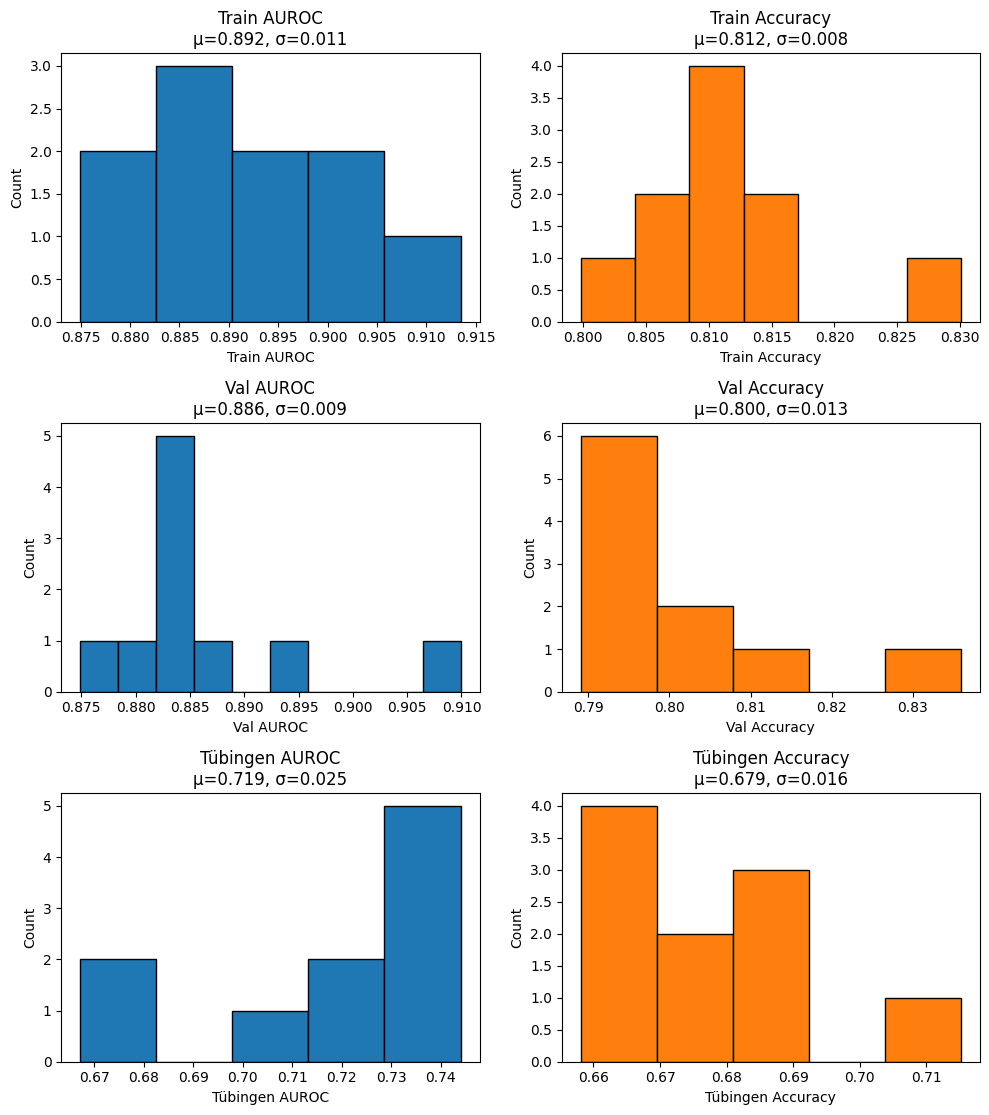

In [39]:
make_nn_plots(results)